<a href="https://colab.research.google.com/github/UnkindledTwo/perceptual_backbone_ldct/blob/main/perceptual_backbone_ldct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 - Data Preparation and Screening
- BIAI dataset dataset_biailab_I2I_2025v1.zip is downloaded and extracted

- github repo UnkindledTwo/perceptual_backbone_ldct is cloned and src is added to path

- Dataloaders are prepared; value range, image shape and splits are checked for leakage


In [1]:
# Download and unzip dataset
!gdown 1pIUT5beAkp17WCxyGPHZfHy4kEiJtD4y&export=download
!unzip dataset_biailab_I2I_2025v1.zip

Downloading...
From (original): https://drive.google.com/uc?id=1pIUT5beAkp17WCxyGPHZfHy4kEiJtD4y
From (redirected): https://drive.google.com/uc?id=1pIUT5beAkp17WCxyGPHZfHy4kEiJtD4y&confirm=t&uuid=7d0ede28-c06c-4e12-90d5-a6c703cade2c
To: /content/dataset_biailab_I2I_2025v1.zip
100% 5.74G/5.74G [01:25<00:00, 67.2MB/s]
Archive:  dataset_biailab_I2I_2025v1.zip
   creating: minideeplesion/
  inflating: __MACOSX/._minideeplesion  
   creating: minideeplesion/test/
  inflating: __MACOSX/minideeplesion/._test  
   creating: minideeplesion/train/
  inflating: __MACOSX/minideeplesion/._train  
   creating: minideeplesion/val/
  inflating: __MACOSX/minideeplesion/._val  
  inflating: minideeplesion/test/001286_01_02_049.png.npz  
  inflating: __MACOSX/minideeplesion/test/._001286_01_02_049.png.npz  
  inflating: minideeplesion/test/001276_01_02_161.png.npz  
  inflating: __MACOSX/minideeplesion/test/._001276_01_02_161.png.npz  
  inflating: minideeplesion/test/001276_04_02_173.png.npz  
  inflati

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

WEIGHTS_PATH = Path("/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Clone repo and add to path
!git clone https://github.com/UnkindledTwo/perceptual_backbone_ldct

Cloning into 'perceptual_backbone_ldct'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 117 (delta 31), reused 85 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 9.50 MiB | 15.77 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [4]:
import torch
from pathlib import Path

import sys
sys.path.append("/content/perceptual_backbone_ldct/src")
sys.path.append("/content/perceptual_backbone_ldct")

from config import PerceptualConfig
config_screening = PerceptualConfig(run_name="screening-c0", data_root=Path("/content/minideeplesion/"))

In [5]:
from pathlib import Path
from data import assert_no_patient_leakage

patient_leakage = assert_no_patient_leakage(Path(config_screening.data_root))
print("Patients per split:",patient_leakage)

Patients per split: {'train': 115, 'val': 34, 'test': 31}


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

train_file_path = config_screening.data_root.as_posix() + '/train/*.npz'
test_file_path = config_screening.data_root.as_posix() + '/test/*.npz'
val_file_path = config_screening.data_root.as_posix() + '/val/*.npz'

# Find all files
train_files = sorted(glob(train_file_path))
test_files = sorted(glob(test_file_path))
val_files = sorted(glob(val_file_path))

print(f"Training samples: {len(train_files)}")
print(f"Test samples: {len(test_files)}")
print(f"Eval samples: {len(val_files)}")

# Load a single file
data = np.load(train_files[0])
print(f"Available arrays: {data.files}")

# Access the arrays
gt_image = data[config_screening.target_key]
noisy_image = data[config_screening.input_key]

print(f"Image shape: {gt_image.shape}")
print(f"Value range: [{gt_image.min():.3f}, {gt_image.max():.3f}]")

Training samples: 899
Test samples: 220
Eval samples: 182
Available arrays: ['gt_full', 'gt_clipped', 'noisy_clipped_10k', 'noisy_clipped_50k', 'noisy_clipped_100k', 'noisy_clipped_500k', 'noisy_clipped_1000k']
Image shape: (512, 512)
Value range: [0.000, 1.000]


In [7]:
from data import I2IPairs
from torch.utils.data import DataLoader

# Dataloaders
splits = {s: I2IPairs(Path(config_screening.data_root / s), config_screening.input_key, config_screening.target_key) for s in ("train", "val", "test")}
train_loader = DataLoader(splits["train"], batch_size=config_screening.batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(splits["val"], batch_size=config_screening.batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(splits["test"], batch_size=config_screening.batch_size, shuffle=False, num_workers=4)

## Identity Test for Metrics

In [8]:
!pip install lpips piq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 9.5 MB/s eta 0:00:00


In [9]:
# Identity test for psnr, ssim, lpips-alex, dists and R_h
from metrics import slice_metrics, save_per_slice_metrics

noisy, gt, _ = next(iter((test_loader)))

noisy_2d = noisy[0].squeeze().cpu().numpy()
gt_2d = gt[0].squeeze().cpu().numpy()

# Run the metrics on this single slice
metrics_noisy = slice_metrics(noisy_2d, gt_2d)
metrics_gt = slice_metrics(gt_2d, gt_2d)

print(metrics_noisy)
print(metrics_gt)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 209MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth
Downloading: "https://github.com/photosynthesis-team/piq/releases/download/v0.4.1/dists_weights.pt" to /root/.cache/torch/hub/checkpoints/dists_weights.pt


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


/usr/local/lib/python3.13/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


{'psnr': 21.04514212137338, 'ssim': 0.7044619018468344, 'lpips': 0.4944991171360016, 'dists': 0.21444714069366455, 'r_h': 24.50556433833073}
{'psnr': inf, 'ssim': 1.0, 'lpips': 0.0, 'dists': 1.1920928955078125e-07, 'r_h': 1.0}


### Check the crop method and the loader sanity

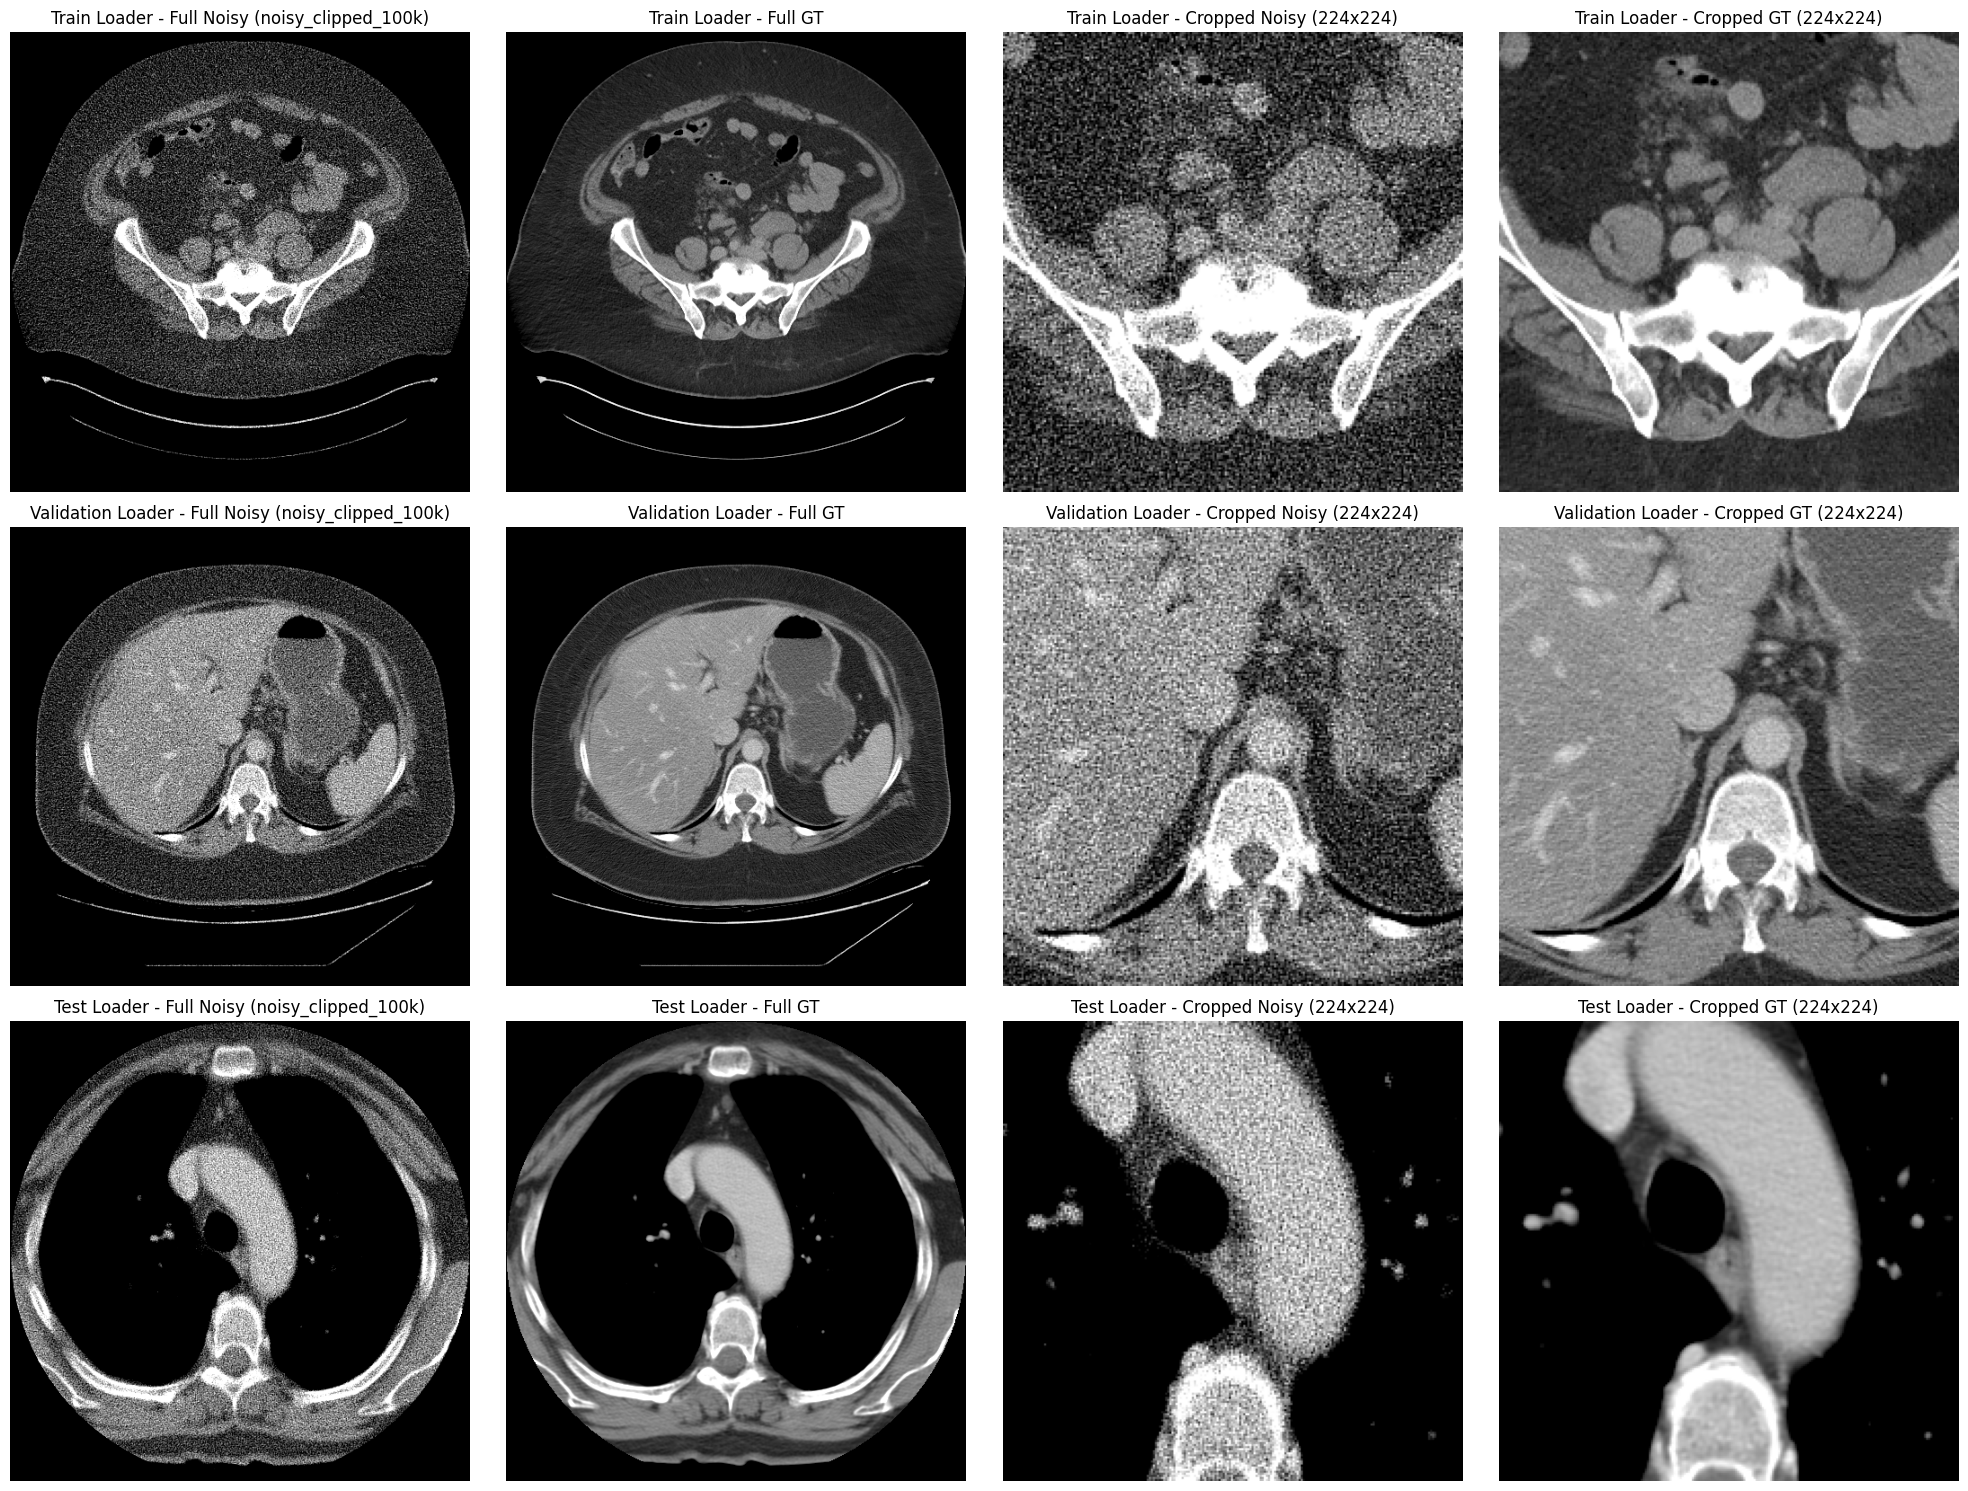

In [10]:
import matplotlib.pyplot as plt

# Configure the loaders dictionary
loaders = {
    "Train Loader": train_loader,
    "Validation Loader": val_loader,
    "Test Loader": test_loader
}

# Set up a grid of 3 loaders x 4 plots (Full Noisy, Full GT, Cropped Noisy, Cropped GT)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
crop_size = config_screening.crop_size

for idx, (name, loader) in enumerate(loaders.items()):
    # Fetch one batch
    noisy_batch, gt_batch, _ = next(iter(loader))

    # Get raw single-channel arrays
    noisy_img = noisy_batch[0].squeeze().cpu().numpy()
    gt_img = gt_batch[0].squeeze().cpu().numpy()

    # Perform center crop identical to screen_network's logic (offset = (512 - crop) // 2)
    h, w = noisy_img.shape
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2

    noisy_cropped = noisy_img[start_h:start_h + crop_size, start_w:start_w + crop_size]
    gt_cropped = gt_img[start_h:start_h + crop_size, start_w:start_w + crop_size]

    # 1. Plot Full Noisy
    axes[idx, 0].imshow(noisy_img, cmap='gray')
    axes[idx, 0].set_title(f"{name} - Full Noisy ({config_screening.input_key})")
    axes[idx, 0].axis('off')

    # 2. Plot Full Ground Truth
    axes[idx, 1].imshow(gt_img, cmap='gray')
    axes[idx, 1].set_title(f"{name} - Full GT")
    axes[idx, 1].axis('off')

    # 3. Plot Cropped Noisy
    axes[idx, 2].imshow(noisy_cropped, cmap='gray')
    axes[idx, 2].set_title(f"{name} - Cropped Noisy ({crop_size}x{crop_size})")
    axes[idx, 2].axis('off')

    # 4. Plot Cropped Ground Truth
    axes[idx, 3].imshow(gt_cropped, cmap='gray')
    axes[idx, 3].set_title(f"{name} - Cropped GT ({crop_size}x{crop_size})")
    axes[idx, 3].axis('off')

plt.tight_layout()
plt.show()

In [11]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [12]:
from model import UNet

# Init U-Net

model = UNet().to(device)
model.eval()

UNet(
  (encoder): ModuleList(
    (0): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace

## Train C0 (l1) and time

In [ ]:
from train import train_and_test
import time
import random

print("Seed:", config_screening.seed)
random.seed(config_screening.seed)

criterion = torch.nn.functional.l1_loss

start_time = time.time()
df_test = train_and_test(config=config_screening, model=model, criterion=criterion, device=device)
end_time = time.time()
total_time = end_time - start_time
print("Total time", total_time)
print(f"Total training time: {total_time:.2f} seconds")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth
Seed: 42


screening-c0: 100%|██████████| 30/30 [09:05<00:00, 18.19s/it]


Total time 612.3778066635132
Total training time: 612.38 seconds


In [ ]:
summary = {
    "psnr_pred_mean":  float(df_test["psnr"].mean()),
    "psnr_pred_std":   float(df_test["psnr"].std(ddof=1)),
    "ssim_pred_mean":  float(df_test["ssim"].mean()),
    "ssim_pred_std":   float(df_test["ssim"].std(ddof=1)),
    "lpips_pred_mean":  float(df_test["lpips"].mean()),
    "lpips_pred_std":   float(df_test["lpips"].std(ddof=1)),
    "dists_pred_mean":  float(df_test["dists"].mean()),
    "dists_pred_std":   float(df_test["dists"].std(ddof=1)),
    "r_h_pred_mean":  float(df_test["r_h"].mean()),
    "r_h_pred_std":   float(df_test["r_h"].std(ddof=1)),
    "n_test": int(len(df_test)),
    "total_time": total_time,
}

print("\n=== TEST RESULTS (mean \u00b1 std) ===")
print(f"Model  PSNR: {summary["psnr_pred_mean"]:.2f} \u00b1 {summary["psnr_pred_std"]:.2f} dB")
print(f"Model  SSIM: {summary["ssim_pred_mean"]:.4f} \u00b1 {summary["ssim_pred_std"]:.4f}")
print(f"Model  LP\u0130PS: {summary["lpips_pred_mean"]:.4f} \u00b1 {summary["lpips_pred_std"]:.4f}")
print(f"Model  DISTS: {summary["dists_pred_mean"]:.4f} \u00b1 {summary["dists_pred_std"]:.4f}")
print(f"Model  R_H: {summary["r_h_pred_mean"]:.4f} \u00b1 {summary["r_h_pred_std"]:.4f}")

print(f"Test samples: {summary["n_test"]}")

save_per_slice_metrics([summary], config_screening.run_dir / "summary.csv")


=== TEST RESULTS (mean ± std) ===
Model  PSNR: 30.83 ± 1.94 dB
Model  SSIM: 0.8723 ± 0.0930
Model  LPİPS: 0.1009 ± 0.0728
Model  DISTS: 0.1101 ± 0.0210
Model  R_H: 0.6045 ± 0.1945
Test samples: 220


,psnr_pred_mean,psnr_pred_std,ssim_pred_mean,ssim_pred_std,lpips_pred_mean,lpips_pred_std,dists_pred_mean,dists_pred_std,r_h_pred_mean,r_h_pred_std,n_test,total_time
0,30.825891,1.943627,0.872268,0.092972,0.100909,0.072848,0.110051,0.021038,0.604507,0.194472,220,612.377807


### Evaluating Baseline Metrics (Noisy vs Ground Truth)

In [ ]:
import pandas as pd
from tqdm import tqdm
from metrics import slice_metrics

baseline_metrics = []

# Iterate through the test loader to calculate metrics on raw inputs
for noisy_batch, gt_batch, _ in tqdm(test_loader, desc="Evaluating Baseline"):
    for i in range(noisy_batch.size(0)):
        noisy_2d = noisy_batch[i].squeeze().cpu().numpy()
        gt_2d = gt_batch[i].squeeze().cpu().numpy()

        # Compute metrics between noisy input and ground truth target
        metrics = slice_metrics(noisy_2d, gt_2d)
        baseline_metrics.append(metrics)

# Convert to DataFrame and summarize
df_baseline = pd.DataFrame(baseline_metrics)
save_per_slice_metrics(df_baseline, config_screening.run_dir / "baseline_metrics.csv")
baseline_summary = {
    "psnr_raw_mean":  float(df_baseline["psnr"].mean()),
    "psnr_raw_std":   float(df_baseline["psnr"].std(ddof=1)),
    "ssim_raw_mean":  float(df_baseline["ssim"].mean()),
    "ssim_raw_std":   float(df_baseline["ssim"].std(ddof=1)),
    "lpips_raw_mean":  float(df_baseline["lpips"].mean()),
    "lpips_raw_std":   float(df_baseline["lpips"].std(ddof=1)),
    "dists_raw_mean":  float(df_baseline["dists"].mean()),
    "dists_raw_std":   float(df_baseline["dists"].std(ddof=1)),
    "r_h_raw_mean":  float(df_baseline["r_h"].mean()),
    "r_h_raw_std":   float(df_baseline["r_h"].std(ddof=1)),
    "n_test": len(df_baseline)
}

print("\n=== RAW NOISY INPUT TEST RESULTS (mean \u00b1 std) ===")
print(f"Raw PSNR: {baseline_summary["psnr_raw_mean"]:.2f} \u00b1 {baseline_summary["psnr_raw_std"]:.2f} dB")
print(f"Raw SSIM: {baseline_summary["ssim_raw_mean"]:.4f} \u00b1 {baseline_summary["ssim_raw_std"]:.4f}")
print(f"Raw LPIPS: {baseline_summary["lpips_raw_mean"]:.4f} \u00b1 {baseline_summary["lpips_raw_std"]:.4f}")
print(f"Raw DISTS: {baseline_summary["dists_raw_mean"]:.4f} \u00b1 {baseline_summary["dists_raw_std"]:.4f}")
print(f"Raw R_H: {baseline_summary["r_h_raw_mean"]:.4f} \u00b1 {baseline_summary["r_h_raw_std"]:.4f}")

save_per_slice_metrics([baseline_summary], config_screening.run_dir / "baseline_summary.csv")

Evaluating Baseline: 100%|██████████| 28/28 [01:03<00:00,  2.27s/it]


=== RAW NOISY INPUT TEST RESULTS (mean ± std) ===
Raw PSNR: 23.04 ± 2.13 dB
Raw SSIM: 0.7423 ± 0.0647
Raw LPIPS: 0.2843 ± 0.0959
Raw DISTS: 0.1641 ± 0.0462
Raw R_H: 6.1743 ± 5.8560


,psnr_raw_mean,psnr_raw_std,ssim_raw_mean,ssim_raw_std,lpips_raw_mean,lpips_raw_std,dists_raw_mean,dists_raw_std,r_h_raw_mean,r_h_raw_std,n_test
0,23.039831,2.134886,0.742302,0.064748,0.284252,0.095883,0.164106,0.046221,6.174314,5.856038,220


## Build Feature Nets and do the network zoo screening test

In [13]:
!pip install -q huggingface_hub

### HUGGINGFACE AUTH skip here to authorize in HF for medsiglip weights

In [14]:
from huggingface_hub import hf_hub_download
import huggingface_hub
import os

huggingface_hub.login()

radimagenet_weights_path = hf_hub_download(repo_id="Lab-Rasool/RadImageNet", filename="ResNet50.pt")
print(f"Successfully downloaded RadImageNet weights to: {radimagenet_weights_path}")

ResNet50.pt: reconstructing file:   0%|          |  0.00B / 94.3MB            

ResNet50.pt: downloading bytes:           |  0.00B            

Successfully downloaded RadImageNet weights to: /root/.cache/huggingface/hub/models--Lab-Rasool--RadImageNet/snapshots/14460ee4c1276f6925611a63aa9a54a05d39eae0/ResNet50.pt


In [15]:
from feature_nets import build_feature_net

random_tensor = torch.rand(64, 64)
random_tensor = random_tensor.unsqueeze(0).unsqueeze(0)

vggnet = build_feature_net("vgg19")
radimagenet_net = build_feature_net("radimagenet", radimagenet_weights_path)
dinov2_s_net = build_feature_net("dinov2_s")
dinov2_b_net = build_feature_net("dinov2_b")
dinov2_l_net = build_feature_net("dinov2_l")
medsiglipnet = build_feature_net("medsiglip")
clip_b16net = build_feature_net("clip_b16")

from distances import PiqDistance
lpips_distance = PiqDistance("lpips_vgg")
dists_distance = PiqDistance("dists")

networks = {
    "VGG19": vggnet,
    "RadImageNet": radimagenet_net,
    "DINOv2_S": dinov2_s_net,
    "DINOv2_B": dinov2_b_net,
    "DINOv2_L": dinov2_l_net,
    "MedSigLIP": medsiglipnet,
    "CLIP_B16": clip_b16net
}

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 221MB/s]


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


...

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_at

Downloading: "https://github.com/photosynthesis-team/photosynthesis.metrics/releases/download/v0.4.0/lpips_weights.pt" to /root/.cache/torch/hub/checkpoints/lpips_weights.pt


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

In [17]:
import pandas as pd
import time
import torch
import distances
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = []
batch_size = 8
img_size = 224

random.seed(config_screening.seed)

print(f"Benchmarking on {device}...")
print("Seed", config_screening.seed)

for name, net in networks.items():
    net = net.to(device)
    net.eval()

    # 1. Distance when pred == target
    pred_ident = torch.rand(1, 1, img_size, img_size, device=device)
    target_ident = pred_ident.clone()
    feat_pred = net.features(pred_ident)
    feat_target = net.features(target_ident)

    dist_ident_pw = distances.pointwise_distance(feat_pred, feat_target).item()
    dist_ident_stat = distances.statistics_distance(feat_pred, feat_target).item()

    # 2a. Gradient check (Pointwise)
    pred_pw = torch.rand(1, 1, img_size, img_size, requires_grad=True, device=device)
    target_pw = torch.rand(1, 1, img_size, img_size, device=device)
    loss_pw = distances.pointwise_distance(net.features(pred_pw), net.features(target_pw))
    loss_pw.backward()
    has_grad_pw = pred_pw.grad is not None and pred_pw.grad.abs().sum().item() > 0

    # 2b. Gradient check (Statistics)
    pred_stat = torch.rand(1, 1, img_size, img_size, requires_grad=True, device=device)
    target_stat = torch.rand(1, 1, img_size, img_size, device=device)
    loss_stat = distances.statistics_distance(net.features(pred_stat), net.features(target_stat))
    loss_stat.backward()
    has_grad_stat = pred_stat.grad is not None and pred_stat.grad.abs().sum().item() > 0

    # 3. Speed test (ms per batch of 8)
    try:
        # Warmup
        for _ in range(2):
            p_w = torch.rand(batch_size, 1, img_size, img_size, requires_grad=True, device=device)
            t_w = torch.rand(batch_size, 1, img_size, img_size, device=device)
            f_p = net.features(p_w)
            f_t = net.features(t_w)
            distances.pointwise_distance(f_p, f_t).backward(retain_graph=True)
            distances.statistics_distance(f_p, f_t).backward()

        n_iters = 5
        start_events_pw = [torch.cuda.Event(enable_timing=True) for _ in range(n_iters)]
        end_events_pw = [torch.cuda.Event(enable_timing=True) for _ in range(n_iters)]

        start_events_stat = [torch.cuda.Event(enable_timing=True) for _ in range(n_iters)]
        end_events_stat = [torch.cuda.Event(enable_timing=True) for _ in range(n_iters)]

        for i in range(n_iters):
            # Timing Pointwise
            p_bench_pw = torch.rand(batch_size, 1, img_size, img_size, requires_grad=True, device=device)
            t_bench_pw = torch.rand(batch_size, 1, img_size, img_size, device=device)
            start_events_pw[i].record()
            loss_p = distances.pointwise_distance(net.features(p_bench_pw), net.features(t_bench_pw))
            loss_p.backward()
            end_events_pw[i].record()

            # Timing Statistics
            p_bench_stat = torch.rand(batch_size, 1, img_size, img_size, requires_grad=True, device=device)
            t_bench_stat = torch.rand(batch_size, 1, img_size, img_size, device=device)
            start_events_stat[i].record()
            loss_s = distances.statistics_distance(net.features(p_bench_stat), net.features(t_bench_stat))
            loss_s.backward()
            end_events_stat[i].record()

        torch.cuda.synchronize()
        times_pw = [s.elapsed_time(e) for s, e in zip(start_events_pw, end_events_pw)]
        avg_time_pw = sum(times_pw) / n_iters

        times_stat = [s.elapsed_time(e) for s, e in zip(start_events_stat, end_events_stat)]
        avg_time_stat = sum(times_stat) / n_iters

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            avg_time_pw = "OOM"
            avg_time_stat = "OOM"
            torch.cuda.empty_cache()
        else:
            avg_time_pw = f"Error"
            avg_time_stat = f"Error"
            print(f"{name} Error: {e}")

    results.append({
        "Network": name,
        "PW Dist (pred=tgt)": f"{dist_ident_pw:.6f}",
        "PW Dist ~0": dist_ident_pw < 1e-5,
        "PW Grad": has_grad_pw,
        "PW Time (ms)": avg_time_pw,
        "Stat Dist (pred=tgt)": f"{dist_ident_stat:.6f}",
        "Stat Dist ~0": dist_ident_stat < 1e-5,
        "Stat Grad": has_grad_stat,
        "Stat Time (ms)": avg_time_stat
    })

    # Move net back to CPU and clear cache to avoid OOM for subsequent models
    net = net.cpu()
    torch.cuda.empty_cache()


df_benchmark = pd.DataFrame(results)
display(df_benchmark)
save_per_slice_metrics(df_benchmark, config_screening.run_dir / "benchmark_distances.csv")

Benchmarking on cuda...
Seed 42


,Network,PW Dist (pred=tgt),PW Dist ~0,PW Grad,PW Time (ms),Stat Dist (pred=tgt),Stat Dist ~0,Stat Grad,Stat Time (ms)
0,VGG19,0.000000,True,True,21.121843,0.000000,True,True,22.315007
1,RadImageNet,0.000000,True,True,32.565043,0.000000,True,True,36.788838
2,DINOv2_S,0.000000,True,True,51.943628,0.000000,True,True,53.089895
3,DINOv2_B,0.000000,True,True,141.385730,0.000000,True,True,142.832233
4,DINOv2_L,0.000000,True,True,441.194092,0.000000,True,True,442.922394
5,MedSigLIP,0.000000,True,True,2381.381445,0.000000,True,True,2386.905908
6,CLIP_B16,0.000000,True,True,102.415359,0.000000,True,True,103.544218


,Network,PW Dist (pred=tgt),PW Dist ~0,PW Grad,PW Time (ms),Stat Dist (pred=tgt),Stat Dist ~0,Stat Grad,Stat Time (ms)
0,VGG19,0.000000,True,True,21.121843,0.000000,True,True,22.315007
1,RadImageNet,0.000000,True,True,32.565043,0.000000,True,True,36.788838
2,DINOv2_S,0.000000,True,True,51.943628,0.000000,True,True,53.089895
3,DINOv2_B,0.000000,True,True,141.385730,0.000000,True,True,142.832233
4,DINOv2_L,0.000000,True,True,441.194092,0.000000,True,True,442.922394
5,MedSigLIP,0.000000,True,True,2381.381445,0.000000,True,True,2386.905908
6,CLIP_B16,0.000000,True,True,102.415359,0.000000,True,True,103.544218


In [18]:
import pandas as pd
import time
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Benchmarking PiqDistance metrics on {device}...")

piq_metrics = {
    "LPIPS (VGG)": lpips_distance,
    "DISTS": dists_distance
}

piq_results = []
batch_size = 8
img_size = 224

for name, metric in piq_metrics.items():
    # 1. Distance when pred == target
    # PiqDistance typically expects [B, C, H, W]
    pred_ident = torch.rand(1, 1, img_size, img_size, device=device)
    target_ident = pred_ident.clone()

    dist_ident = metric(pred_ident, target_ident).item()

    # 2. Gradient check
    pred_grad = torch.rand(1, 1, img_size, img_size, requires_grad=True, device=device)
    target_grad = torch.rand(1, 1, img_size, img_size, device=device)
    loss = metric(pred_grad, target_grad)
    loss.backward()
    has_grad = pred_grad.grad is not None and pred_grad.grad.abs().sum().item() > 0

    # 3. Speed test (ms per batch of 8)
    try:
        # Warmup
        for _ in range(2):
            p_w = torch.rand(batch_size, 1, img_size, img_size, requires_grad=True, device=device)
            t_w = torch.rand(batch_size, 1, img_size, img_size, device=device)
            metric(p_w, t_w).backward()

        n_iters = 5
        start_events = [torch.cuda.Event(enable_timing=True) for _ in range(n_iters)]
        end_events = [torch.cuda.Event(enable_timing=True) for _ in range(n_iters)]


        for i in range(n_iters):
            p_bench = torch.rand(batch_size, 1, img_size, img_size, requires_grad=True, device=device)
            t_bench = torch.rand(batch_size, 1, img_size, img_size, device=device)

            start_events[i].record()
            loss_bench = metric(p_bench, t_bench)
            loss_bench.backward()
            end_events[i].record()

        torch.cuda.synchronize()
        times = [s.elapsed_time(e) for s, e in zip(start_events, end_events)]
        avg_time = sum(times) / n_iters

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            avg_time = "OOM"
            torch.cuda.empty_cache()
        else:
            avg_time = f"Error: {e}"

    piq_results.append({
        "Metric": name,
        "Identity Dist (pred=tgt)": f"{dist_ident:.6f}",
        "Identity ~0": dist_ident < 1e-5,
        "Gradients Functional": has_grad,
        "Time (ms per batch of 8)": avg_time
    })

df_piq_benchmark = pd.DataFrame(piq_results)
display(df_piq_benchmark)
save_per_slice_metrics(df_piq_benchmark, config_screening.run_dir / "benchmark_distances_lpips_dists.csv")

Benchmarking PiqDistance metrics on cuda...


,Metric,Identity Dist (pred=tgt),Identity ~0,Gradients Functional,Time (ms per batch of 8)
0,LPIPS (VGG),0.000000,True,True,23.672423
1,DISTS,0.000000,True,True,24.860058


,Metric,Identity Dist (pred=tgt),Identity ~0,Gradients Functional,Time (ms per batch of 8)
0,LPIPS (VGG),0.000000,True,True,23.672423
1,DISTS,0.000000,True,True,24.860058


In [ ]:
from screen import screen_network
from pathlib import Path
import torch.nn.functional as F

### Comprehensive Metric Screening for Feature Networks
We will now run the screening across the validation set for the requested metrics and network backbones, computing:
1. **Ordering Score ($M_\phi$)**: Spearman's rank correlation over the 5 dose levels.
2. **Dose Ratio ($D_\phi(10k) / D_\phi(1000k)$)**: Indicating distance scale change across dose variations.
3. **Blur Penalty ($B_\phi$)**: Evaluating sensitivity to blur relative to equivalent-MSE noise levels.

In [20]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from screen import screen_network
import distances

val_paths = [Path(f) for f in val_files]

# Helper to extract and count network parameters
def get_param_count(model):
    if model is None:
        return 0
    return sum(p.numel() for p in model.parameters())

# We will collect final statistics for each network/matching configuration
screen_table_results = []

# 1. Pixel L1 Reference
def pixel_l1_distance(x, y):
    return torch.mean(torch.abs(x - y))

print("Screening Pixel L1 (Reference)...")
df_l1 = screen_network(pixel_l1_distance, val_paths, device)
l1_m_phi = df_l1["ordering"].mean()
l1_ratio = df_l1["d_10000"].mean() / (df_l1["d_1000000"].mean() + 1e-8)
l1_b_phi = df_l1["d_blur"].sum() / (df_l1["d_100000"].sum() + 1e-8)

screen_table_results.append({
    "Network": "Pixel L1 (reference)",
    "Matching": "-",
    "Ordering M_phi": f"{l1_m_phi:.4f}",
    "D_10k / D_1000k": f"{l1_ratio:.4f}",
    "Blur penalty B_phi": f"{l1_b_phi:.4f}",
    "Parameters": "0"
})

# 2. Setup evaluations for all model and distance pairings
configs = [
    {"name": "VGG-19 relu3_2", "net": vggnet, "matching": "pointwise", "dist_fn": distances.pointwise_distance},
    {"name": "LPIPS-VGG", "net": None, "matching": "pointwise", "dist_fn": lpips_distance},
    {"name": "DISTS", "net": None, "matching": "statistics", "dist_fn": dists_distance},
    {"name": "RadImageNet ResNet-50", "net": radimagenet_net, "matching": "pointwise", "dist_fn": distances.pointwise_distance},
    {"name": "DINOv2-S", "net": dinov2_s_net, "matching": "pointwise", "dist_fn": distances.pointwise_distance},
    {"name": "DINOv2-S", "net": dinov2_s_net, "matching": "statistics", "dist_fn": distances.statistics_distance},
    {"name": "DINOv2-B", "net": dinov2_b_net, "matching": "pointwise", "dist_fn": distances.pointwise_distance},
    {"name": "DINOv2-L", "net": dinov2_l_net, "matching": "pointwise", "dist_fn": distances.pointwise_distance},
    {"name": "CLIP ViT-B/16", "net": clip_b16net, "matching": "pointwise", "dist_fn": distances.pointwise_distance},
    {"name": "MedSigLIP-448", "net": medsiglipnet, "matching": "pointwise", "dist_fn": distances.pointwise_distance}
]

for cfg in configs:
    print(f"Screening {cfg['name']} ({cfg['matching']})...")
    net = cfg["net"]
    dist_fn = cfg["dist_fn"]

    # Calculate parameter count
    param_count = "-" if net is None else f"{get_param_count(net):,}"

    if net is not None:
        net = net.to(device)
        net.eval()
        # Wrap distance with feature extraction
        def wrapped_distance(x, y):
            with torch.no_grad():
                return dist_fn(net.features(x), net.features(y))
        eval_fn = wrapped_distance
    else:
        # Directly callable metric (LPIPS/DISTS)
        eval_fn = dist_fn

    try:
        df_res = screen_network(eval_fn, val_paths, device)
        m_phi = df_res["ordering"].mean()
        ratio = df_res["d_10000"].mean() / (df_res["d_1000000"].mean() + 1e-8)
        b_phi = df_res["d_blur"].sum() / (df_res["d_100000"].sum() + 1e-8)

        screen_table_results.append({
            "Network": cfg["name"],
            "Matching": cfg["matching"],
            "Ordering M_phi": f"{m_phi:.4f}",
            "D_10k / D_1000k": f"{ratio:.4f}",
            "Blur penalty B_phi": f"{b_phi:.4f}",
            "Parameters": param_count
        })
    except Exception as e:
        print(f"Failed to evaluate {cfg['name']}: {e}")
        screen_table_results.append({
            "Network": cfg["name"],
            "Matching": cfg["matching"],
            "Ordering M_phi": "Error",
            "D_10k / D_1000k": "Error",
            "Blur penalty B_phi": "Error",
            "Parameters": param_count
        })

    if net is not None:
        net = net.cpu()
        torch.cuda.empty_cache()

# Create summary table
df_screen_report = pd.DataFrame(screen_table_results)
display(df_screen_report)
save_per_slice_metrics(df_screen_report, config_screening.run_dir / "zoo_screen_report.csv")

Screening Pixel L1 (Reference)...


Screening VGG-19 relu3_2 (pointwise)...


Screening LPIPS-VGG (pointwise)...


Screening DISTS (statistics)...


Screening RadImageNet ResNet-50 (pointwise)...


...

Screening DINOv2-L (pointwise)...


Screening CLIP ViT-B/16 (pointwise)...


Screening MedSigLIP-448 (pointwise)...


,Network,Matching,Ordering M_phi,D_10k / D_1000k,Blur penalty B_phi,Parameters
0,Pixel L1 (reference),-,1.0000,5.7366,0.8861,0
1,VGG-19 relu3_2,pointwise,1.0000,2.6057,1.5092,"1,145,408"
2,LPIPS-VGG,pointwise,0.9984,2.4252,1.4825,-
3,DISTS,statistics,0.9835,2.7509,1.4495,-
4,RadImageNet ResNet-50,pointwise,0.9538,7.1007,1.8118,"25,557,032"
5,DINOv2-S,pointwise,0.9978,7.7117,1.7518,"22,056,576"
6,DINOv2-S,statistics,0.9973,2.3666,1.2604,"22,056,576"
7,DINOv2-B,pointwise,0.9973,6.2713,1.6694,"86,580,480"
8,DINOv2-L,pointwise,0.9956,6.8865,1.8737,"304,368,640"
9,CLIP ViT-B/16,pointwise,0.9956,2.7337,1.5710,"85,799,424"


,Network,Matching,Ordering M_phi,D_10k / D_1000k,Blur penalty B_phi,Parameters
0,Pixel L1 (reference),-,1.0000,5.7366,0.8861,0
1,VGG-19 relu3_2,pointwise,1.0000,2.6057,1.5092,"1,145,408"
2,LPIPS-VGG,pointwise,0.9984,2.4252,1.4825,-
3,DISTS,statistics,0.9835,2.7509,1.4495,-
4,RadImageNet ResNet-50,pointwise,0.9538,7.1007,1.8118,"25,557,032"
5,DINOv2-S,pointwise,0.9978,7.7117,1.7518,"22,056,576"
6,DINOv2-S,statistics,0.9973,2.3666,1.2604,"22,056,576"
7,DINOv2-B,pointwise,0.9973,6.2713,1.6694,"86,580,480"
8,DINOv2-L,pointwise,0.9956,6.8865,1.8737,"304,368,640"
9,CLIP ViT-B/16,pointwise,0.9956,2.7337,1.5710,"85,799,424"


# Week 2 - CT Dose network and training

In [21]:
from model import UNet
from config import PerceptualConfig
import random

config_train = PerceptualConfig(run_name="training", data_root="/content/minideeplesion/")

model = UNet().to(device)
model.eval()

random.seed(config_train.seed)
print("Seed", config_train.seed)

Seed 42


## Configurations
| ID | Feature network | Family | Pretraining | Matching | Source |
|---|---|---|---|---|---|
| C0 | none (L1) | reference | - | - | - |
| C1 | VGG-19, relu3_2 | ImageNet CNN | ImageNet classification | pointwise | `viana2025perceptual` (their best layer) |
| C2 | LPIPS-VGG | calibrated CNN | ImageNet + human judgments | pointwise (learned weights) | `zhang2018lpips` |
| C3 | DISTS | texture-statistics IQA | ImageNet + human judgments | statistics (structure and texture) | `ding2020dists` |
| C4 | RadImageNet ResNet-50, layer1 to layer3 | medical CNN | RadImageNet classification | pointwise | `mei2022radimagenet` |
| C5 | DINOv2 ViT-S/14, blocks 3, 6, 9 | self-supervised ViT, small | LVD-142M, self-distillation | pointwise | `oquab2024dinov2` |
| C6 | DINOv2 ViT-B/14, blocks 3, 6, 9 | self-supervised ViT, base | LVD-142M, self-distillation | pointwise | `oquab2024dinov2` |
| C7 | MedSigLIP-448, layers 7, 14, 20 | medical VLM | medical image and text pairs | pointwise | `sellergren2025medgemma` |
| C8 | DINOv2 ViT-S/14, blocks 3, 6, 9 | self-supervised ViT, small | as C5 | local statistics | this paper |
| C9 | CT dose network, blocks 1 to 3 | CT, task-trained (proposed) | dose classification on the train split | pointwise | this paper |
| C10 | CT dose network, blocks 1 to 3 | CT, task-trained (proposed) | as C9 | local statistics | this paper |


In [22]:
import pandas as pd
import torch
import distances
from feature_nets import build_feature_net
from distances import PiqDistance

# Helper for reference Pixel L1
def pixel_l1_distance(x, y):
    return torch.mean(torch.abs(x - y))


### Dynamic Instantiation of Distance Metric Functions (C0 - C10)
We will now map each configuration row to its live PyTorch distance metric or feature-extraction backbone pipeline. This ensures each configuration has a corresponding callable metric `d(x, y)` to serve as our training loss.

In [33]:
import torch
import distances
from feature_nets import build_feature_net
from distances import PiqDistance
from huggingface_hub import hf_hub_download

active_metrics = {}

# Ensure radimagenet_weights_path is defined
try:
    radimagenet_weights_path
except NameError:
    print("Downloading RadImageNet weights on the fly...")
    radimagenet_weights_path = hf_hub_download(repo_id="Lab-Rasool/RadImageNet", filename="ResNet50.pt")

# C0: Pixel L1 Reference
active_metrics["C0"] = lambda x, y: torch.mean(torch.abs(x - y))

# C1: VGG-19, relu3_2 pointwise
if 'vggnet' in globals():
    net_c1 = vggnet
else:
    net_c1 = build_feature_net("vgg19")
active_metrics["C1"] = lambda x, y: distances.pointwise_distance(net_c1.to(device).features(x), net_c1.to(device).features(y))

# C2: LIPS-VGG calibrated
if 'lpips_distance' in globals():
    active_metrics["C2"] = lpips_distance
else:
    active_metrics["C2"] = PiqDistance("lpips_vgg")

# C3: DISTS texture-statistics
if 'dists_distance' in globals():
    active_metrics["C3"] = dists_distance
else:
    active_metrics["C3"] = PiqDistance("dists")

# C4: RadImageNet ResNet-50
if 'radimagenet_net' in globals():
    net_c4 = radimagenet_net
else:
    net_c4 = build_feature_net("radimagenet", radimagenet_weights_path)
active_metrics["C4"] = lambda x, y: distances.pointwise_distance(net_c4.to(device).features(x), net_c4.to(device).features(y))

# C5: DINOv2 ViT-S/14 Pointwise
if 'dinov2_s_net' in globals():
    net_c5 = dinov2_s_net
else:
    net_c5 = build_feature_net("dinov2_s")
active_metrics["C5"] = lambda x, y: distances.pointwise_distance(net_c5.to(device).features(x), net_c5.to(device).features(y))

# C6: DINOv2 ViT-B/14 Pointwise
if 'dinov2_b_net' in globals():
    net_c6 = dinov2_b_net
else:
    net_c6 = build_feature_net("dinov2_b")
active_metrics["C6"] = lambda x, y: distances.pointwise_distance(net_c6.to(device).features(x), net_c6.to(device).features(y))

# C7: MedSigLIP-448 Pointwise
if 'medsiglipnet' in globals():
    net_c7 = medsiglipnet
else:
    net_c7 = build_feature_net("medsiglip")
active_metrics["C7"] = lambda x, y: distances.pointwise_distance(net_c7.to(device).features(x), net_c7.to(device).features(y))

# C8: DINOv2 ViT-S/14 Statistics (local/texture structure matching)
active_metrics["C8"] = lambda x, y: distances.statistics_distance(net_c5.to(device).features(x), net_c5.to(device).features(y))

# C9 & C10: CT Dose task-trained networks (proposed)
try:
    from ct_dose_net import CTDoseNet, DoseNetFeatures
    ct_dose_net = CTDoseNet().to(device)
    ct_dose_net.eval()
    ct_dose_net.load_state_dict(torch.load(
        WEIGHTS_PATH / "ct_dose_net.pt"
        ))
    dn_features = DoseNetFeatures(ct_dose_net)
    active_metrics["C9"] = lambda x, y: distances.pointwise_distance(dn_features.features(x), dn_features.features(y))
    active_metrics["C10"] = lambda x, y: distances.statistics_distance(dn_features.features(x), dn_features.features(y))
    print("Successfully loaded CTDoseNet for C9 and C10.")
except Exception as e:
    print(f"CTDoseNet could not be instantiated for C9/C10 (optional/downstream step): {e}")

print(f"Successfully registered distance metrics for active configs: {list(active_metrics.keys())}")

Successfully loaded CTDoseNet for C9 and C10.
Successfully registered distance metrics for active configs: ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10']


## Calibrate Lambda

In [34]:
import torch
from tqdm import tqdm

def calibrate_weight_influence(model, distance_fn, loader, device, target_perceptual_ratio=0.95, crop_size=224):
    model.eval()
    sum_s1 = 0.0
    sum_sphi = 0.0
    count = 0

    with torch.no_grad():
        for noisy, gt, _ in tqdm(loader, desc="Calibrating"):
            noisy, gt = noisy.to(device), gt.to(device)
            pred = model(noisy)

            # S_1 = L1 loss between prediction and ground truth
            s1_val = torch.nn.functional.l1_loss(pred, gt, reduction='mean').item()
            sum_s1 += s1_val

            # Apply center cropping identical to training spatial configuration
            h, w = pred.shape[-2:]
            start_h = (h - crop_size) // 2
            start_w = (w - crop_size) // 2

            pred_cropped = pred[..., start_h:start_h + crop_size, start_w:start_w + crop_size]
            gt_cropped = gt[..., start_h:start_h + crop_size, start_w:start_w + crop_size]

            # S_phi = Perceptual distance (using mean over batch)
            sphi_val = distance_fn(pred_cropped, gt_cropped).mean().item()
            sum_sphi += sphi_val

            count += noisy.size(0)

    # Calculate mean values over the evaluated batches
    num_batches = len(loader)
    mean_s1 = sum_s1 / num_batches
    mean_sphi = sum_sphi / num_batches

    if mean_sphi == 0:
        return 0.0, mean_s1, mean_sphi

    # lambda = (target_ratio / (1 - target_ratio)) * (S_1 / S_phi)
    factor = target_perceptual_ratio / (1.0 - target_perceptual_ratio)
    lambda_val = factor * (mean_s1 / mean_sphi)
    return lambda_val, mean_s1, mean_sphi

perceptual_weights = {}
# Calibrate all registered metrics and store the three calibration values
print("Seed", config_train.seed)
random.seed(config_train.seed)

for metric_id, distance_fn in active_metrics.items():
    print(f"\n--- Calibrating weights for {metric_id} ---")
    lambda_val, s1_val, sphi_val = calibrate_weight_influence(model, distance_fn, train_loader, device)
    perceptual_weights[metric_id] = {
        "lambda": lambda_val,
        "S_1": s1_val,
        "S_phi": sphi_val
    }
    print(f"{metric_id} -> lambda: {lambda_val:.6f} | S_1 (mean): {s1_val:.6f} | S_phi (mean): {sphi_val:.6f}")

Seed 42

--- Calibrating weights for C0 ---


Calibrating: 100%|██████████| 113/113 [00:07<00:00, 14.89it/s]


C0 -> lambda: 8.987834 | S_1 (mean): 0.207796 | S_phi (mean): 0.439274

--- Calibrating weights for C1 ---


Calibrating: 100%|██████████| 113/113 [00:08<00:00, 13.70it/s]


C1 -> lambda: 3.071802 | S_1 (mean): 0.207062 | S_phi (mean): 1.280741

--- Calibrating weights for C2 ---


...

C8 -> lambda: 1.775290 | S_1 (mean): 0.207370 | S_phi (mean): 2.219374

--- Calibrating weights for C9 ---


Calibrating: 100%|██████████| 113/113 [00:08<00:00, 13.96it/s]


C9 -> lambda: 0.933939 | S_1 (mean): 0.206940 | S_phi (mean): 4.209972

--- Calibrating weights for C10 ---


Calibrating: 100%|██████████| 113/113 [00:08<00:00, 13.95it/s]

C10 -> lambda: 1.730200 | S_1 (mean): 0.207460 | S_phi (mean): 2.278194


In [35]:
# Create Pandas DataFrame and render
df_calibration = pd.DataFrame(perceptual_weights)
display(df_calibration)

import os

# Define output path using config_train's run directory
cal_save_path = config_train.run_dir / "calibration_weights.csv"
os.makedirs(config_train.run_dir, exist_ok=True)

# Save the dataframe
df_calibration.to_csv(cal_save_path)
print(f"Calibration dataframe successfully saved to: {cal_save_path}")

,C0,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10
lambda,8.987834,3.071802,5.854840,5.069944,1.333242,1.666934,2.115241,2.764184,1.775290,0.933939,1.730200
S_1,0.207796,0.207062,0.207112,0.207622,0.207185,0.207100,0.207527,0.207696,0.207370,0.206940,0.207460
S_phi,0.439274,1.280741,0.672115,0.778080,2.952587,2.360563,1.864094,1.427629,2.219374,4.209972,2.278194


Calibration dataframe successfully saved to: outputs/perceptual_backbone/training/calibration_weights.csv


## Train CTDoseNet


- [ ] Build 128 × 128 patches from **train-split patients only**, labelled by
      source: the 5 dose keys and `gt_clipped` (6 classes)
- [ ] Train 10 epochs with cross-entropy; report val accuracy and the
      confusion matrix
- [ ] Freeze it and run the Step 1.4 screen on it (both matchings)

$$
\mathcal{L}_{\mathrm{dose}} = -\frac{1}{B} \sum_{b=1}^{B} \log \operatorname{softmax}\big(g_\psi(p_b)\big)_{y_b}, \qquad y_b \in \{10\mathrm{k}, 50\mathrm{k}, 100\mathrm{k}, 500\mathrm{k}, 1000\mathrm{k}, \mathrm{clean}\}
$$

where $p_b$ is a patch and $g_\psi$ the network; its block outputs are the
features $\phi_l$ used in (1) and (2).


`DoseNetFeatures` takes the 1-channel crop directly (it does not call
`prepare`). Sample patches with random positions inside the body mask and
train with Adam, learning rate $10^{-3}$, batch 64.

| Check | Expected | Observed |
|---|---|---|
| Val accuracy, 6 classes | well above 1/6; 10k and clean easy, 500k vs 1000k hardest | - |
| Val accuracy, clean vs 1000k | above chance | - |
| Screen ordering $M_\phi$ | close to 1 | - |
| Screen blur penalty $B_\phi$ | report; below 1 is a finding, not a bug | - |

**Gotcha:** a network trained only to tell noise levels apart may treat a
blurred slice as "clean" (the same smoothness bias as the MedSigLIP IQA
model). Do not add blurred patches to its training to fix the screen, because
that tunes it to the test. Report $B_\phi$ as measured and let C10 (local
statistics) show whether matching the texture spread avoids the problem.

In [24]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class DoseClassificationPatchDataset(Dataset):
    def __init__(self, file_paths, patch_size=128, patches_per_image=4, seed=42):
        self.file_paths = file_paths
        self.patch_size = patch_size
        self.patches_per_image = patches_per_image
        self.rng = np.random.default_rng(seed)

        # 6 Target classes mapping
        self.class_keys = [
            "noisy_clipped_10k",
            "noisy_clipped_50k",
            "noisy_clipped_100k",
            "noisy_clipped_500k",
            "noisy_clipped_1000k",
            "gt_clipped"
        ]

        # Pre-build patch indices to avoid loading files entirely on the fly during training iterations
        self.samples = []
        for f_path in self.file_paths:
            for _ in range(self.patches_per_image):
                # Random top-left corner coordinates for the patch inside a 512x512 image
                y = self.rng.integers(0, 512 - patch_size)
                x = self.rng.integers(0, 512 - patch_size)
                # Add a sample for each of the 6 classes
                for class_idx in range(6):
                    self.samples.append((f_path, y, x, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        f_path, y, x, class_idx = self.samples[idx]
        data = np.load(f_path)

        key = self.class_keys[class_idx]
        full_image = data[key]

        # Extract patch and cast to tensor
        patch = full_image[y : y + self.patch_size, x : x + self.patch_size]
        patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0)  # Shape [1, 128, 128]

        return patch_tensor, class_idx

# Instantiate using the train_files (which are pre-filtered to contain only train-split patients)
train_patch_dataset = DoseClassificationPatchDataset(train_files, patch_size=128, patches_per_image=4)
train_patch_loader = DataLoader(train_patch_dataset, batch_size=64, shuffle=True, num_workers=4)

# 1. Build validation patch dataset to report true validation metrics (6 classes)
val_patch_dataset = DoseClassificationPatchDataset(val_files, patch_size=128, patches_per_image=4, seed=42)
val_patch_loader = DataLoader(val_patch_dataset, batch_size=64, shuffle=False, num_workers=4)

print(f"Created patch dataset with {len(train_patch_dataset)} total samples (6 classes per patch location).")

Created patch dataset with 21576 total samples (6 classes per patch location).


In [25]:
import numpy as np
import torch

# 1. Check Spatial Dimensions and Data Range
print("=== Testing Patch Dataloader Batches ===")
train_batch_inputs, train_batch_labels = next(iter(train_patch_loader))
val_batch_inputs, val_batch_labels = next(iter(val_patch_loader))

print(f"Train batch input shape: {train_batch_inputs.shape} (Expected: [B, 1, 128, 128])")
print(f"Train batch labels shape: {train_batch_labels.shape} (Expected: [B])")
print(f"Train batch intensity range: [{train_batch_inputs.min().item():.4f}, {train_batch_inputs.max().item():.4f}] (Expected close to [0.0, 1.0])")

print(f"\nVal batch input shape: {val_batch_inputs.shape} (Expected: [B, 1, 128, 128])")
print(f"Val batch intensity range: [{val_batch_inputs.min().item():.4f}, {val_batch_inputs.max().item():.4f}]")

# 2. Check Patient Leakage in Patch Datasets
print("\n=== Checking for Patient Leakage between Splits ===")
train_patient_ids = set(p.split('/')[-1].split('_')[0] for p in train_files)
val_patient_ids = set(p.split('/')[-1].split('_')[0] for p in val_files)
overlap = train_patient_ids.intersection(val_patient_ids)

print(f"Unique patients in Train split: {len(train_patient_ids)}")
print(f"Unique patients in Validation split: {len(val_patient_ids)}")
if len(overlap) == 0:
    print("SUCCESS: No patient leakage detected! The patient sets are completely disjoint.")
else:
    print(f"WARNING: Patient leakage detected! Overlapping patients: {overlap}")

=== Testing Patch Dataloader Batches ===
Train batch input shape: torch.Size([64, 1, 128, 128]) (Expected: [B, 1, 128, 128])
Train batch labels shape: torch.Size([64]) (Expected: [B])
Train batch intensity range: [0.0000, 1.0000] (Expected close to [0.0, 1.0])

Val batch input shape: torch.Size([64, 1, 128, 128]) (Expected: [B, 1, 128, 128])
Val batch intensity range: [0.0000, 1.0000]

=== Checking for Patient Leakage between Splits ===
Unique patients in Train split: 115
Unique patients in Validation split: 34
SUCCESS: No patient leakage detected! The patient sets are completely disjoint.


Seed 42
Starting CTDoseNet Training for 10 epochs...
Epoch 01/10 | Train Loss: 0.8159 | Train Acc: 68.06%
Epoch 02/10 | Train Loss: 0.6087 | Train Acc: 76.53%
Epoch 03/10 | Train Loss: 0.5306 | Train Acc: 79.74%
Epoch 04/10 | Train Loss: 0.5272 | Train Acc: 79.37%
Epoch 05/10 | Train Loss: 0.4723 | Train Acc: 82.24%
Epoch 06/10 | Train Loss: 0.4436 | Train Acc: 82.71%
Epoch 07/10 | Train Loss: 0.4114 | Train Acc: 84.27%
Epoch 08/10 | Train Loss: 0.3924 | Train Acc: 84.99%
Epoch 09/10 | Train Loss: 0.3918 | Train Acc: 84.98%
Epoch 10/10 | Train Loss: 0.3747 | Train Acc: 85.82%

Final Validation Accuracy: 79.49%


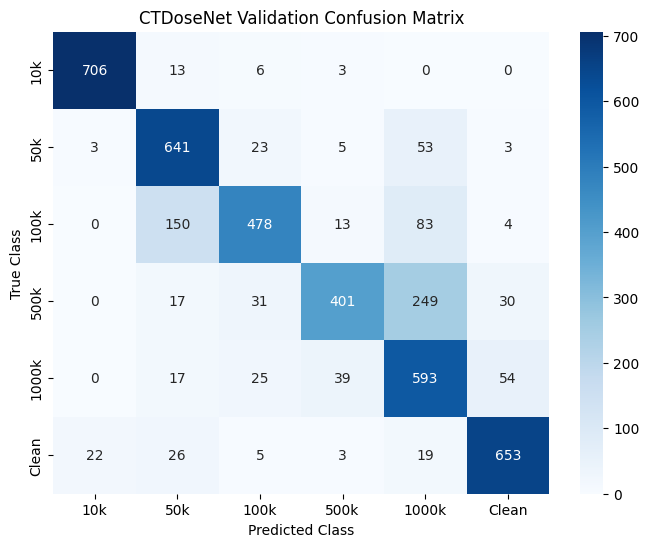


Classification Report:
              precision    recall  f1-score   support

         10k       0.97      0.97      0.97       728
         50k       0.74      0.88      0.81       728
        100k       0.84      0.66      0.74       728
        500k       0.86      0.55      0.67       728
       1000k       0.59      0.81      0.69       728
       Clean       0.88      0.90      0.89       728

    accuracy                           0.79      4368
   macro avg       0.81      0.79      0.79      4368
weighted avg       0.81      0.79      0.79      4368



In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from ct_dose_net import CTDoseNet

random.seed(config_train.seed)
torch.cuda.manual_seed(config_train.seed)
print("Seed", config_train.seed)
# 2. Setup training components
dosenet = CTDoseNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(dosenet.parameters(), lr=1e-3)
epochs = 10

print("Starting CTDoseNet Training for 10 epochs...")
for epoch in range(epochs):
    dosenet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_patch_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = dosenet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_patch_loader.dataset)
    epoch_acc = 100.0 * correct / total
    print(f"Epoch {epoch+1:02d}/10 | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%")

# 3. Validation Evaluation
dosenet.eval()
val_correct = 0
val_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_patch_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = dosenet(inputs)
        _, predicted = outputs.max(1)

        val_total += labels.size(0)
        val_correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

val_accuracy = 100.0 * val_correct / val_total
print(f"\nFinal Validation Accuracy: {val_accuracy:.2f}%")

# 4. Compute Confusion Matrix
class_names = ["10k", "50k", "100k", "500k", "1000k", "Clean"]
cm = confusion_matrix(all_labels, all_preds)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("CTDoseNet Validation Confusion Matrix")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [28]:
import torch
import os

# Define model save path
weights_save_path = config_train.run_dir / "ct_dose_net.pt"
os.makedirs(config_train.run_dir, exist_ok=True)

# Save model state dictionary
torch.save(dosenet.state_dict(), weights_save_path)
print(f"Successfully saved CTDoseNet weights to: {weights_save_path}")

Successfully saved CTDoseNet weights to: outputs/perceptual_backbone/training/ct_dose_net.pt


In [29]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

# Ensure the output directory exists
output_dir = config_train.run_dir
os.makedirs(output_dir, exist_ok=True)

# 1. Save Validation Accuracy
val_acc_file = output_dir / "dosenet_val_accuracy.txt"
with open(val_acc_file, "w") as f:
    f.write(f"Final Validation Accuracy: {val_accuracy:.2f}%\n")
print(f"Saved validation accuracy to: {val_acc_file}")

# 2. Save Classification Report
report_txt = classification_report(all_labels, all_preds, target_names=class_names)
report_file = output_dir / "dosenet_classification_report.txt"
with open(report_file, "w") as f:
    f.write(report_txt)
print(f"Saved classification report text to: {report_file}")

# Also save report as a CSV for easy parsing
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
report_csv_file = output_dir / "dosenet_classification_report.csv"
df_report.to_csv(report_csv_file)
print(f"Saved classification report CSV to: {report_csv_file}")

# 3. Save Confusion Matrix
cm_file = output_dir / "dosenet_confusion_matrix.npy"
np.save(cm_file, cm)
print(f"Saved raw confusion matrix to: {cm_file}")

df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_csv_file = output_dir / "dosenet_confusion_matrix.csv"
df_cm.to_csv(cm_csv_file)
print(f"Saved confusion matrix CSV to: {cm_csv_file}")

Saved validation accuracy to: outputs/perceptual_backbone/training/dosenet_val_accuracy.txt
Saved classification report text to: outputs/perceptual_backbone/training/dosenet_classification_report.txt
Saved classification report CSV to: outputs/perceptual_backbone/training/dosenet_classification_report.csv
Saved raw confusion matrix to: outputs/perceptual_backbone/training/dosenet_confusion_matrix.npy
Saved confusion matrix CSV to: outputs/perceptual_backbone/training/dosenet_confusion_matrix.csv


In [31]:
import torch
import pandas as pd
from pathlib import Path
from screen import screen_network
import distances
from ct_dose_net import DoseNetFeatures


# 1. Freeze CTDoseNet weights and load weights
dosenet = CTDoseNet().to(device)
dose_net_path = WEIGHTS_PATH /"ct_dose_net.pt"
dosenet.load_state_dict(torch.load(dose_net_path, map_location=device))

dosenet.eval()
for param in dosenet.parameters():
    param.requires_grad = False


# 2. Extract features using the frozen trained model
dn_features = DoseNetFeatures(dosenet)

# 3. Define matching functions
# C9: Pointwise matching using CTDoseNet features
def metric_c9(x, y):
    with torch.no_grad():
        return distances.pointwise_distance(dn_features.features(x), dn_features.features(y))

# C10: Statistics matching using CTDoseNet features
def metric_c10(x, y):
    with torch.no_grad():
        return distances.statistics_distance(dn_features.features(x), dn_features.features(y))

# 4. Run Screen Evaluation on Validation Files
val_paths = [Path(f) for f in val_files]
print("Screening C9 (CTDoseNet Pointwise)...")
df_c9 = screen_network(metric_c9, val_paths, device)

print("Screening C10 (CTDoseNet Statistics)...")
df_c10 = screen_network(metric_c10, val_paths, device)

# 5. Compute metric summaries
def compute_summaries(df):
    m_phi = df["ordering"].mean()
    ratio = df["d_10000"].mean() / (df["d_1000000"].mean() + 1e-8)
    b_phi = df["d_blur"].sum() / (df["d_100000"].sum() + 1e-8)
    return m_phi, ratio, b_phi

m_phi_c9, ratio_c9, b_phi_c9 = compute_summaries(df_c9)
m_phi_c10, ratio_c10, b_phi_c10 = compute_summaries(df_c10)

param_count = sum(p.numel() for p in dosenet.parameters())

# 6. Report results in a clean table format
screen_results = [
    {
        "Configuration": "C9 (CTDoseNet Pointwise)",
        "Ordering M_phi": f"{m_phi_c9:.4f}",
        "D_10k / D_1000k": f"{ratio_c9:.4f}",
        "Blur penalty B_phi": f"{b_phi_c9:.4f}",
        "Parameters": f"{param_count:,}"
    },
    {
        "Configuration": "C10 (CTDoseNet Statistics)",
        "Ordering M_phi": f"{m_phi_c10:.4f}",
        "D_10k / D_1000k": f"{ratio_c10:.4f}",
        "Blur penalty B_phi": f"{b_phi_c10:.4f}",
        "Parameters": f"{param_count:,}"
    }
]

df_screen_results = pd.DataFrame(screen_results)
display(df_screen_results)

# Save to the run output directory
df_screen_results.to_csv(config_train.run_dir / "ctdosenet_screen_report.csv", index=False)
print("Saved screen report to disk.")

Screening C9 (CTDoseNet Pointwise)...


Screening C10 (CTDoseNet Statistics)...


,Configuration,Ordering M_phi,D_10k / D_1000k,Blur penalty B_phi,Parameters
0,C9 (CTDoseNet Pointwise),0.7066,3.9919,0.3119,"1,175,142"
1,C10 (CTDoseNet Statistics),0.6934,2.1148,0.8143,"1,175,142"


Saved screen report to disk.


## Training C1-C10

In [36]:
from src.config import PerceptualConfig
from src.ct_dose_net import CTDoseNet, DoseNetFeatures
from src.distances import FeatureDistance, PerceptualObjective, PiqDistance
from src.feature_nets import build_feature_net
from src.train import train_and_test


def build_objective(config: PerceptualConfig, dose_net_path: Path, radimagenet: Path | None) -> PerceptualObjective:
    if config.feature_net == "none":
        return PerceptualObjective(None, 0.0)
    if config.feature_net in ("lpips_vgg", "dists"):
        return PerceptualObjective(PiqDistance(config.feature_net), config.loss_weight, config.crop_size)
    if config.feature_net == "ct_dose_net":
        network = CTDoseNet()
        network.load_state_dict(torch.load(dose_net_path, map_location="cpu"))
        net = DoseNetFeatures(network)
    else:
        net = build_feature_net(config.feature_net, radimagenet)
    return PerceptualObjective(FeatureDistance(net, config.matching), config.loss_weight, config.crop_size)


def run(config: PerceptualConfig, dose_net_path: Path, radimagenet: Path | None = None) -> pd.DataFrame:
    device = torch.device("cuda")
    objective = build_objective(config, dose_net_path, radimagenet).to(device)
    return train_and_test(config, UNet().to(device), objective, device)



Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [38]:
import torch
from pathlib import Path
from dataclasses import replace

from config import PerceptualConfig
from pathlib import Path

# Dictionary to hold the custom configs for configurations C1 through C10
configs = {}

# We will use the main training settings and map each config's directory
# to a dedicated subdirectory under config_train.run_dir
for i in range(1, 11):
    config_id = f"C{i}"
    configs[config_id] = PerceptualConfig(
        run_name=f"train_{config_id}",
        data_root=Path("/content/minideeplesion/")
    )

print("Successfully instantiated PerceptualConfig objects for:", list(configs.keys()))

# Path to the saved CTDoseNet weights
#dose_net_path = config_train.run_dir / "ct_dose_net.pt"
dose_net_path = WEIGHTS_PATH / "ct_dose_net.pt"

# Path to the saved Radimagenet weights
radimagenet_path = Path(radimagenet_weights_path) if 'radimagenet_weights_path' in globals() else None

# Dictionary to hold the build objectives (loss functions) for C1 through C10
objectives = {}

# Configure each configuration specifically by replacing fields on the frozen dataclass
for config_id in sorted(configs.keys()):
    cfg = configs[config_id]

    # Map config IDs to specific feature networks and matchings
    feature_net = "none"
    matching = "pointwise"

    if config_id == "C1":
        feature_net = "vgg19"
        matching = "pointwise"
    elif config_id == "C2":
        feature_net = "lpips_vgg"
        matching = "pointwise"
    elif config_id == "C3":
        feature_net = "dists"
        matching = "statistics"
    elif config_id == "C4":
        feature_net = "radimagenet"
        matching = "pointwise"
    elif config_id == "C5":
        feature_net = "dinov2_s"
        matching = "pointwise"
    elif config_id == "C6":
        feature_net = "dinov2_b"
        matching = "pointwise"
    elif config_id == "C7":
        feature_net = "medsiglip"
        matching = "pointwise"
    elif config_id == "C8":
        feature_net = "dinov2_s"
        matching = "statistics"
    elif config_id == "C9":
        feature_net = "ct_dose_net"
        matching = "pointwise"
    elif config_id == "C10":
        feature_net = "ct_dose_net"
        matching = "statistics"

    # Extract calibrated lambda weight from df_calibration to loss_weight
    loss_weight = 0.0
    if config_id in df_calibration.columns:
        loss_weight = float(df_calibration.loc["lambda", config_id])

    # Since the config is frozen, use replace() to create a modified copy
    cfg_updated = replace(cfg, feature_net=feature_net, matching=matching, loss_weight=loss_weight)
    configs[config_id] = cfg_updated

    # Build objective
    objectives[config_id] = build_objective(cfg_updated, dose_net_path, radimagenet_path)

print("Successfully configured objectives for:", list(objectives.keys()))

Successfully instantiated PerceptualConfig objects for: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10']


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Successfully configured objectives for: ['C1', 'C10', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']


In [39]:
import torch

# Create a dummy batch to verify forward compatibility [B, C, H, W]
x_dummy = torch.rand(2, 1, 224, 224, device="cuda")
y_dummy = torch.rand(2, 1, 224, 224, device="cuda")

print(f"{'Config':<8} | {'Feature Net':<18} | {'Matching':<12} | {'Loss Weight':<12} | {'Status/Dummy Loss':<12}")
print("-" * 72)

for config_id in sorted(configs.keys()):
    cfg = configs[config_id]
    objective = objectives.get(config_id)

    if objective is None:
        print(f"{config_id:<8} | {cfg.feature_net:<18} | {cfg.matching:<12} | {cfg.loss_weight:<12.5f} | Missing Objective!")
        continue

    try:
        # Ensure objective is on GPU
        objective = objective.to("cuda")
        # Compute objective loss
        loss_val = objective(x_dummy, y_dummy).item()
        status = f"{loss_val:.6f}"
    except Exception as e:
        status = f"Error: {str(e)[:20]}..."

    print(f"{config_id:<8} | {cfg.feature_net:<18} | {cfg.matching:<12} | {cfg.loss_weight:<12.5f} | {status:<12}")


Config   | Feature Net        | Matching     | Loss Weight  | Status/Dummy Loss
------------------------------------------------------------------------
C1       | vgg19              | pointwise    | 3.07180      | 2.698390    
C10      | ct_dose_net        | statistics   | 1.73020      | 1.079150    
C2       | lpips_vgg          | pointwise    | 5.85484      | 2.243939    
C3       | dists              | statistics   | 5.06994      | 0.989989    
C4       | radimagenet        | pointwise    | 1.33324      | 0.813693    
C5       | dinov2_s           | pointwise    | 1.66693      | 2.938083    
C6       | dinov2_b           | pointwise    | 2.11524      | 3.431068    
C7       | medsiglip          | pointwise    | 2.76418      | 2.271708    
C8       | dinov2_s           | statistics   | 1.77529      | 2.137152    
C9       | ct_dose_net        | pointwise    | 0.93394      | 1.709218    


In [45]:
import time
import pandas as pd
import random

results_report = {}

# Loop over configurations C1 through C10, run training, and report completion times
for config_id in sorted(configs.keys()):
    print(f"\n>>> Starting training for configuration {config_id}...")
    if (config_id != "C4") and (config_id != "C10"):
      continue
    cfg = configs[config_id]
    random.seed(cfg.seed)
    torch.cuda.manual_seed(cfg.seed)

    start_time = time.time()
    try:
        # run() is defined as run(config, dose_net_path, radimagenet)
        df_test_results = run(cfg, dose_net_path, radimagenet_path)

        elapsed = time.time() - start_time
        results_report[config_id] = {
            "status": "Success",
            "time_elapsed_sec": elapsed,
            "mean_psnr": float(df_test_results["psnr"].mean()) if "psnr" in df_test_results else None
        }
        summary = {
    "psnr_pred_mean":  float(df_test_results["psnr"].mean()),
    "psnr_pred_std":   float(df_test_results["psnr"].std(ddof=1)),
    "ssim_pred_mean":  float(df_test_results["ssim"].mean()),
    "ssim_pred_std":   float(df_test_results["ssim"].std(ddof=1)),
    "lpips_pred_mean":  float(df_test_results["lpips"].mean()),
    "lpips_pred_std":   float(df_test_results["lpips"].std(ddof=1)),
    "dists_pred_mean":  float(df_test_results["dists"].mean()),
    "dists_pred_std":   float(df_test_results["dists"].std(ddof=1)),
    "r_h_pred_mean":  float(df_test_results["r_h"].mean()),
    "r_h_pred_std":   float(df_test_results["r_h"].std(ddof=1)),
    "n_test": int(len(df_test_results)),
    "total_time": elapsed,
}
        print(summary)

        print(f"\n<<< [FINISHED] Configuration {config_id} completed successfully in {elapsed:.2f} seconds!")
    except Exception as e:
        elapsed = time.time() - start_time
        results_report[config_id] = {
            "status": f"Failed: {str(e)}",
            "time_elapsed_sec": elapsed,
            "mean_psnr": None
        }
        print(f"\n<<< [FAILED] Configuration {config_id} crashed after {elapsed:.2f} seconds. Error: {e}")

# Final summary display of run status
print("\n=================== TRAINING RUN SUMMARY ===================")
for config_id, summary in results_report.items():
    status = summary["status"]
    duration = summary["time_elapsed_sec"]
    metric_info = f"| Mean PSNR: {summary['mean_psnr']:.2f} dB" if summary["mean_psnr"] is not None else ""
    print(f"Config {config_id:<5} : Status: {status:<10} | Time: {duration:6.2f}s {metric_info}")



>>> Starting training for configuration C1...

>>> Starting training for configuration C10...


train_C10: 100%|██████████| 30/30 [09:52<00:00, 19.76s/it]



<<< [FAILED] Configuration C10 crashed after 654.95 seconds. Error: name 'total_time' is not defined

>>> Starting training for configuration C2...

>>> Starting training for configuration C3...

>>> Starting training for configuration C4...


train_C4: 100%|██████████| 30/30 [09:54<00:00, 19.80s/it]



<<< [FAILED] Configuration C4 crashed after 657.64 seconds. Error: name 'total_time' is not defined

>>> Starting training for configuration C5...

>>> Starting training for configuration C6...

>>> Starting training for configuration C7...

>>> Starting training for configuration C8...

>>> Starting training for configuration C9...

=================== TRAINING RUN SUMMARY ===================
Config C10   : Status: Failed: name 'total_time' is not defined | Time: 654.95s 
Config C4    : Status: Failed: name 'total_time' is not defined | Time: 657.64s 


/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/best_c1.pth
/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/best_c2.pth
/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/best_c3.pth
/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/best_c4.pth
/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/best_c5.pth
/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/best_c6.pth
/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/best_c7.pth
/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/best_c8.pth
/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/best_c9.pth
/content/drive/MyDrive/BIAI/ISBI2027_WEIGHTS/best_c10.pth


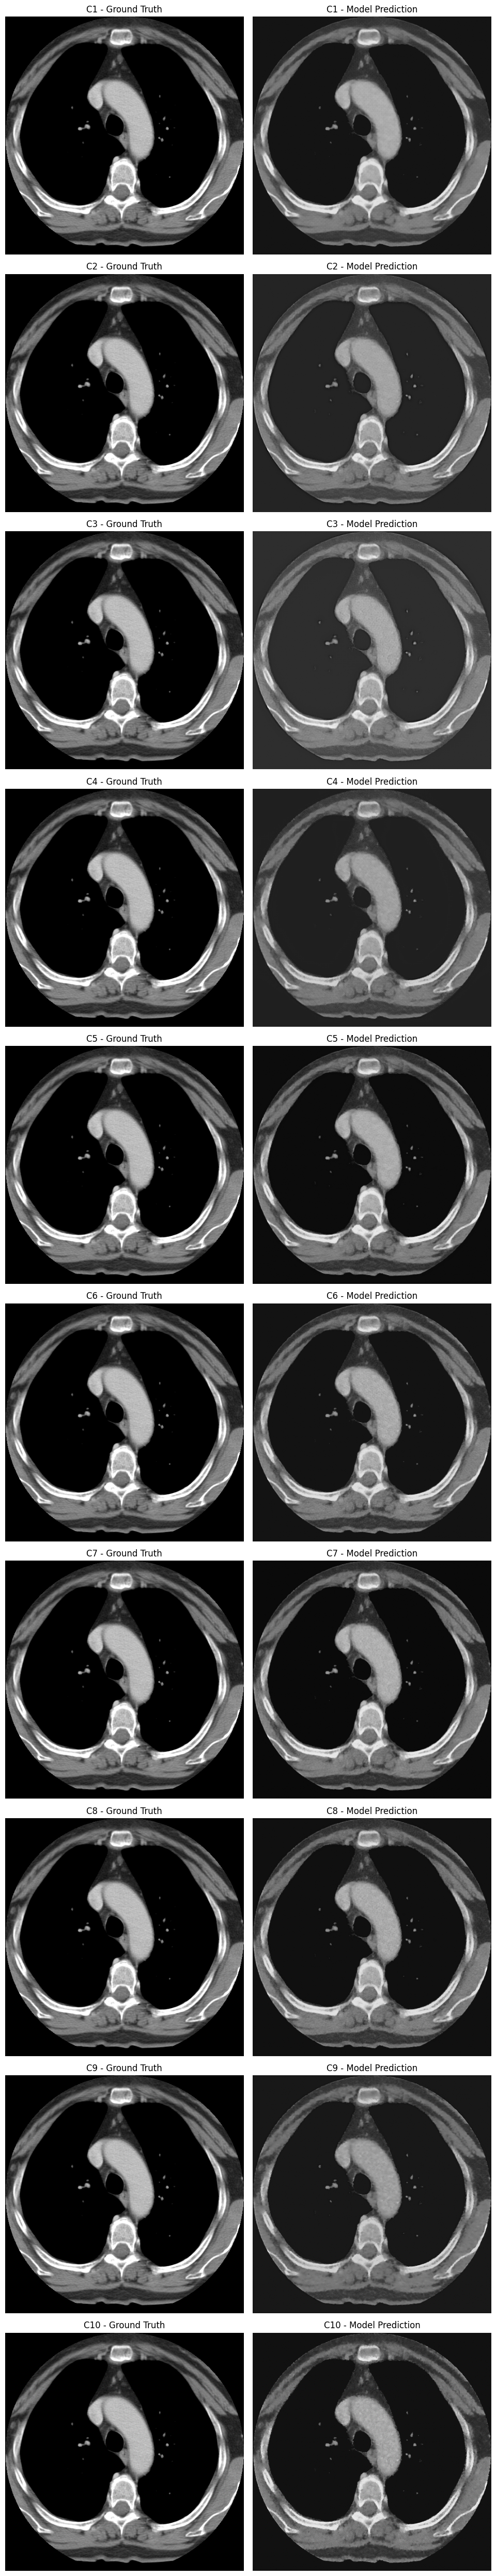

In [47]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from model import UNet

# Prepare sample test data
noisy_batch, gt_batch, _ = next(iter(test_loader))
noisy_sample = noisy_batch[0:1].to(device)  # Shape [1, 1, 512, 512]
gt_img = gt_batch[0].squeeze().cpu().numpy()  # Grayscale ground truth

# We will visualize the first few configurations (C1 through C10)
configs_to_show = [f"C{i}" for i in range(1, 11)]

fig, axes = plt.subplots(len(configs_to_show), 2, figsize=(10, 5 * len(configs_to_show)))

for idx, config_id in enumerate(configs_to_show):
    # Re-initialize a fresh UNet model
    eval_model = UNet().to(device)
    eval_model.eval()

    # Point to the saved weight file inside each run's output directory
    # Note: If weights are in Drive (e.g. WEIGHTS_PATH / ...), adapt path appropriately
    file_name = f"best_{config_id.lower()}.pth"
    weight_file = WEIGHTS_PATH/file_name.lower()
    print(weight_file)
    if not weight_file.exists():
      print("FAIL TO LOAD", config_id)
        # Fallback to general output paths
      weight_file = Path(f"{WEIGHTS_PATH}/best_{config_id}.pth")

    if weight_file.exists():
        try:
            eval_model.load_state_dict(torch.load(weight_file, map_location=device))
            with torch.no_grad():
                pred_batch = eval_model(noisy_sample)
                pred_img = pred_batch[0].squeeze().cpu().numpy()

            # Plot Ground Truth
            axes[idx, 0].imshow(gt_img, cmap='gray')
            axes[idx, 0].set_title(f"{config_id} - Ground Truth")
            axes[idx, 0].axis('off')

            # Plot Model Prediction
            axes[idx, 1].imshow(pred_img, cmap='gray')
            axes[idx, 1].set_title(f"{config_id} - Model Prediction")
            axes[idx, 1].axis('off')
        except Exception as e:
            print(f"Could not load or visualize {config_id}: {e}")
    else:
        print(f"Weight checkpoint not found for {config_id} at {weight_file}")

plt.tight_layout()
plt.show()

In [50]:
import os
import pandas as pd
from pathlib import Path

# Define the possible directories where metric files are saved
search_paths = [
    Path("/content/outputs/perceptual_backbone"),
    Path("/content/perceptual_backbone_ldct/results")
]

summary_records = []

# We check for all configurations C0 to C10
for i in range(11):
    config_id = f"C{i}"
    # Map config folder names dynamically
    folder_names = [f"train_{config_id}", f"train_{config_id.lower()}", f"screening-c0" if config_id == "C0" else ""]

    metrics_file = None
    # Scan paths
    for base_path in search_paths:
        for folder in folder_names:
            if not folder:
                continue
            # We search for metrics.csv or any metrics file like metrics_c0.csv
            for file_name in ["metrics.csv", "metrics_c0.csv"]:
                test_file = base_path / folder / file_name
                if test_file.exists():
                    metrics_file = test_file
                    break
            if metrics_file:
                break
        if metrics_file:
            break

    if metrics_file and metrics_file.exists():
        try:
            df = pd.read_csv(metrics_file)
            # Make sure we only calculate stats on valid metrics
            target_cols = [c for c in ["psnr", "ssim", "lpips", "dists", "r_h"] if c in df.columns]
            if target_cols:
                means = df[target_cols].mean()
                stds = df[target_cols].std(ddof=1)

                record = {"Config": config_id}
                for col in ["psnr", "ssim", "lpips", "dists", "r_h"]:
                    if col in means:
                        record[f"{col.upper()}_mean"] = means[col]
                        record[f"{col.upper()}_std"] = stds[col]
                    else:
                        record[f"{col.upper()}_mean"] = None
                        record[f"{col.upper()}_std"] = None
                summary_records.append(record)
        except Exception as e:
            print(f"Error reading {config_id} from {metrics_file}: {e}")
    else:
        # Check if C0 summary exists in screening-c0/summary.csv as a fallback
        c0_summary_file = Path("/content/outputs/perceptual_backbone/screening-c0/summary.csv")
        if config_id == "C0" and c0_summary_file.exists():
            try:
                df_sum = pd.read_csv(c0_summary_file)
                summary_records.append({
                    "Config": "C0",
                    "PSNR_mean": df_sum.get("psnr_pred_mean", [None])[0],
                    "PSNR_std": df_sum.get("psnr_pred_std", [None])[0],
                    "SSIM_mean": df_sum.get("ssim_pred_mean", [None])[0],
                    "SSIM_std": df_sum.get("ssim_pred_std", [None])[0],
                    "LPIPS_mean": df_sum.get("lpips_pred_mean", [None])[0],
                    "LPIPS_std": df_sum.get("lpips_pred_std", [None])[0],
                    "DISTS_mean": df_sum.get("dists_pred_mean", [None])[0],
                    "DISTS_std": df_sum.get("dists_pred_std", [None])[0],
                    "R_H_mean": df_sum.get("r_h_pred_mean", [None])[0],
                    "R_H_std": df_sum.get("r_h_pred_std", [None])[0]
                })
            except Exception as e:
                pass

if summary_records:
    df_summary = pd.DataFrame(summary_records)

    # Generate a user-friendly table with formatted Mean ± Std
    display_records = []
    for _, row in df_summary.iterrows():
        disp = {"Config": row["Config"]}
        for metric in ["PSNR", "SSIM", "LPIPS", "DISTS", "R_H"]:
            m = row[f"{metric}_mean"]
            s = row[f"{metric}_std"]
            if m is not None and s is not None:
                decimals = 2 if metric == "PSNR" else 4
                disp[metric] = f"{m:.{decimals}f} ± {s:.{decimals}f}"
            else:
                disp[metric] = "N/A"
        display_records.append(disp)

    df_display = pd.DataFrame(display_records)

    print("\n=== Consolidating Metric Summaries (C0 to C10) ===")
    display(df_display)
else:
    print("No configuration metric CSV files found under output directory paths.")


=== Consolidating Metric Summaries (C0 to C10) ===


,Config,PSNR,SSIM,LPIPS,DISTS,R_H
0,C0,30.99 ± 2.05,0.8637 ± 0.0958,0.1070 ± 0.0823,0.1175 ± 0.0230,0.6391 ± 0.2067
1,C1,30.22 ± 2.00,0.8578 ± 0.0975,0.0714 ± 0.0421,0.0798 ± 0.0181,0.7315 ± 0.1910
2,C2,30.67 ± 1.91,0.8691 ± 0.0763,0.0517 ± 0.0216,0.0593 ± 0.0127,0.8296 ± 0.1687
3,C3,29.98 ± 1.86,0.8581 ± 0.0775,0.0521 ± 0.0209,0.0632 ± 0.0146,0.8674 ± 0.2340
4,C4,28.81 ± 1.37,0.8211 ± 0.0753,0.0806 ± 0.0259,0.0867 ± 0.0196,0.7024 ± 0.2562
5,C5,30.67 ± 1.95,0.8658 ± 0.0851,0.0507 ± 0.0240,0.0648 ± 0.0150,0.7179 ± 0.1811
6,C6,30.40 ± 1.79,0.8611 ± 0.0814,0.0559 ± 0.0248,0.0692 ± 0.0138,0.7286 ± 0.2128
7,C7,29.81 ± 1.80,0.8594 ± 0.0884,0.0709 ± 0.0387,0.0706 ± 0.0127,0.5976 ± 0.2090
8,C8,29.25 ± 1.64,0.8559 ± 0.0845,0.0677 ± 0.0323,0.0752 ± 0.0123,0.8384 ± 0.2799
9,C9,30.42 ± 2.02,0.8626 ± 0.0887,0.0739 ± 0.0312,0.0939 ± 0.0163,0.9085 ± 0.1862


In [51]:
import os

# Define output path using config_train's run directory
final_report_csv = config_train.run_dir / "consolidated_metrics_summary.csv"
os.makedirs(config_train.run_dir, exist_ok=True)

# Save the display dataframe containing the 'Mean  Std' formatted values
df_display.to_csv(final_report_csv, index=False)
print(f"Consolidated summary report successfully saved to: {final_report_csv}")

Consolidated summary report successfully saved to: outputs/perceptual_backbone/training/consolidated_metrics_summary.csv


In [52]:
import shutil
from pathlib import Path

# Define paths
source_dir = Path('/content/outputs')
target_zip = Path('/content/drive/MyDrive/outputs_backup')

if source_dir.exists():
    print(f"Compressing and copying {source_dir} to Google Drive...")
    shutil.make_archive(str(target_zip), 'zip', str(source_dir))
    print(f"Successfully saved backup to: {target_zip}.zip")
else:
    print("Error: 'outputs' directory not found!")

Compressing and copying /content/outputs to Google Drive...
Successfully saved backup to: /content/drive/MyDrive/outputs_backup.zip
